# Experiment 09: Cellular Traffic, Channel Capacity, and Erlang-B Blocking Probability Analysis

**Course:** Mobile and Cellular Communication Laboratory  
**Course Code:** ICT-4204  
**Department:** Department of Information and Communication Technology, Islamic University, Kushtia, Bangladesh  
**Implementation:** Python / Jupyter Notebook

---
**Course-source basis:** Course Master Study Notes (offered-load and calls/hour formulas) and William C. Y. Lee reference text / Erlang-B tables and blocking discussion.

> This notebook is an educational laboratory implementation. It keeps the mathematical model simple enough to explain in a practical examination while preserving the core cellular-communication ideas.

## Aim

To analyze cellular traffic load, channel capacity, Grade of Service, and Erlang-B blocking probability.

## Objectives

- Calculate offered traffic in Erlangs.
- Relate calls per hour and holding time to traffic load.
- Calculate call-blocking probability with Erlang B.
- Determine the minimum number of channels for a target Grade of Service.
- Visualize how traffic and channel capacity affect blocking.

## Theory

### Offered traffic

One **Erlang** represents one channel occupied continuously for one hour.

If $Q$ calls are offered per hour and the mean holding time is $T$ minutes,

$$
A=\frac{QT}{60}
$$

If holding time is in seconds,

$$
A=\frac{Q T_s}{3600}
$$

Conversely,

$$
Q=\frac{3600A}{T_s}
$$

The course notes repeatedly use this relationship for cellular traffic calculations.

### Blocking probability and Grade of Service

In a blocked-calls-cleared system, a new call is blocked when all channels are occupied. The **Erlang-B** probability for offered traffic $A$ and $N$ channels can be calculated stably by recursion:

$$
B_0=1
$$

$$
B_n=\frac{A B_{n-1}}{n+A B_{n-1}},
\qquad n=1,2,\dots,N
$$

Then $B_N$ is the final blocking probability.

A common Grade of Service target in the course/reference examples is approximately

$$
B=0.02=2\%
$$

during the busy hour.

The carried traffic can be estimated as

$$
A_c=A(1-B)
$$

and blocked traffic as

$$
A_b=AB
$$

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def erlang_b(offered_traffic, channels):
    B = 1.0
    for n in range(1, channels + 1):
        B = (offered_traffic * B) / (n + offered_traffic * B)
    return B

# Course-style example
offered_traffic_erlangs = 78.3
channels = 90

blocking_probability = erlang_b(offered_traffic_erlangs, channels)
carried_traffic = offered_traffic_erlangs * (1 - blocking_probability)
blocked_traffic = offered_traffic_erlangs * blocking_probability

print(f"Offered traffic       : {offered_traffic_erlangs:.2f} Erlangs")
print(f"Number of channels    : {channels}")
print(f"Blocking probability  : {blocking_probability:.6f}")
print(f"Blocking percentage   : {100*blocking_probability:.3f}%")
print(f"Carried traffic       : {carried_traffic:.3f} Erlangs")
print(f"Blocked traffic       : {blocked_traffic:.3f} Erlangs")

Offered traffic       : 78.30 Erlangs
Number of channels    : 90
Blocking probability  : 0.019980
Blocking percentage   : 1.998%
Carried traffic       : 76.736 Erlangs
Blocked traffic       : 1.564 Erlangs


### Validation Example

For

$$
A=78.3\text{ Erlangs},\qquad N=90
$$

the recursive implementation gives approximately

$$
B\approx0.01998\approx2.0\%
$$

which matches the intended 2% busy-hour blocking level very closely.

In [2]:
# Calls/hour relation used in the course notes
mean_holding_time_s = 100.0
calls_per_hour = 3600 * offered_traffic_erlangs / mean_holding_time_s

print(f"With A = {offered_traffic_erlangs:.1f} Erlangs")
print(f"and mean holding time = {mean_holding_time_s:.0f} s,")
print(f"calls per hour = {calls_per_hour:.1f} ≈ {round(calls_per_hour)} calls/hour")

With A = 78.3 Erlangs
and mean holding time = 100 s,
calls per hour = 2818.8 ≈ 2819 calls/hour


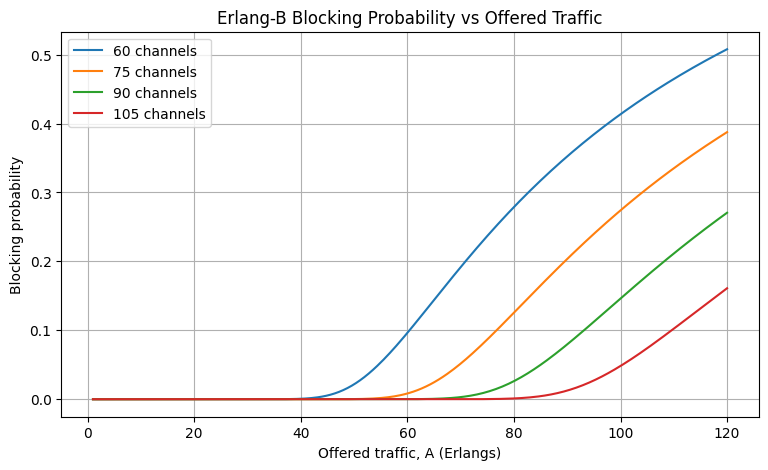

In [3]:
traffic_range = np.linspace(1, 120, 300)
channel_sets = [60, 75, 90, 105]

plt.figure(figsize=(9, 5))
for n_channels in channel_sets:
    blocking = [erlang_b(A, n_channels) for A in traffic_range]
    plt.plot(traffic_range, blocking, label=f"{n_channels} channels")

plt.xlabel("Offered traffic, A (Erlangs)")
plt.ylabel("Blocking probability")
plt.title("Erlang-B Blocking Probability vs Offered Traffic")
plt.legend()
plt.grid(True)
plt.show()

**Observation:** Blocking rises rapidly as offered traffic approaches and exceeds the practical carrying capability of a fixed number of channels. Adding channels shifts the blocking curve downward.

In [4]:
target_gos = 0.02

def minimum_channels_for_gos(offered_traffic, target_blocking, max_channels=500):
    for n_channels in range(1, max_channels + 1):
        if erlang_b(offered_traffic, n_channels) <= target_blocking:
            return n_channels
    return None

min_channels = minimum_channels_for_gos(
    offered_traffic_erlangs,
    target_gos
)

print(f"Minimum channels for A={offered_traffic_erlangs:.1f} Erlangs")
print(f"at GoS B <= {target_gos:.2%}: {min_channels}")

Minimum channels for A=78.3 Erlangs
at GoS B <= 2.00%: 90


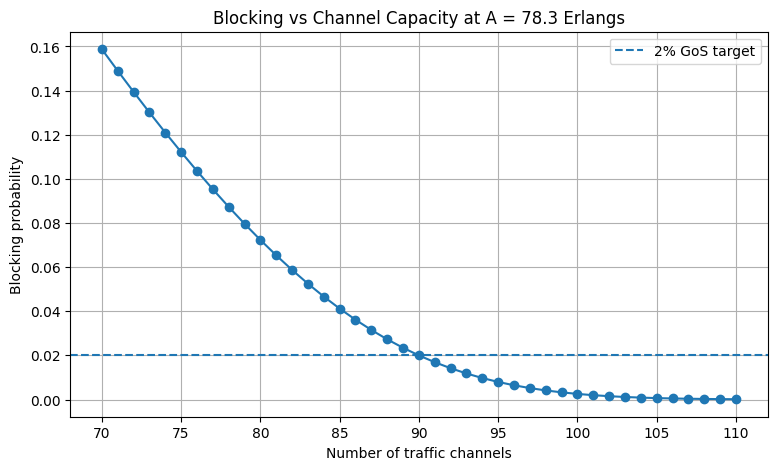

In [5]:
channel_range = np.arange(70, 111)
blocking_by_channels = np.array([
    erlang_b(offered_traffic_erlangs, n) for n in channel_range
])

plt.figure(figsize=(9, 5))
plt.plot(channel_range, blocking_by_channels, marker="o")
plt.axhline(target_gos, linestyle="--", label="2% GoS target")
plt.xlabel("Number of traffic channels")
plt.ylabel("Blocking probability")
plt.title(f"Blocking vs Channel Capacity at A = {offered_traffic_erlangs:.1f} Erlangs")
plt.legend()
plt.grid(True)
plt.show()

## Result and Discussion

For $A=78.3$ Erlangs and $N=90$ channels, Erlang-B blocking is approximately **2%**. The experiment also confirms that more traffic increases blocking while more channels reduce it.

The Erlang-B model assumes blocked calls are cleared rather than queued, so it is appropriate as a simple busy-hour voice-channel model.

## Conclusion

Offered load, calls per hour, channel capacity, and Erlang-B blocking probability were calculated successfully. The simulation also determines the channel count required to meet a target Grade of Service.

## Viva Questions and Short Answers

1. **What is one Erlang?**  
   One channel occupied continuously for one hour.

2. **What is Grade of Service in this experiment?**  
   The accepted call-blocking probability target.

3. **What does Erlang B assume happens to a blocked call?**  
   It is cleared/lost rather than waiting in a queue.

4. **What happens to blocking if offered traffic increases but channels remain fixed?**  
   Blocking probability increases.

5. **What happens to blocking if the number of channels increases for the same traffic?**  
   Blocking probability decreases.